<a href="https://colab.research.google.com/github/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/blob/main/Python%20NoteBooks/Caso_Modelo_Exponencial_inversion_ingresos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Contexto

Se utilizan el conjunto de datos estructurado bivariado que tiene que ver con la relación que hay entre las inversiones en publicidad digital realizadas por un negocio y los ingresos percibidos

Se tienen dos variables de interés:

* inversion
* ingresos


# Objetivo

Implementar, evaluar y comparar calidad predictiva de un modelo de regresión exponencial con otros modelos utilizando datos de inversión e ingresos utilizando funciones de *Python*.

Se evalúan los postulados de linealidad, homocedasticidad, noramldiad e independencia de residuos


Se evalúa la calidad del modelo predicito extrayendo los estadísticos *r square* y *RMSE*. Si el modelo sobrepasa un *90%* en el estadístico *r square* se interpretará como un modelo eficiente en sus prediccionesy será jun parámetro para garantizar rendimiento predictivo.


# Descripción



## Cargar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import scipy.stats as stats

from statsmodels.stats.stattools import durbin_watson

from sklearn.model_selection import train_test_split # Partir datos
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as smf # Para modelo logarítmico

from sklearn.metrics import r2_score, mean_squared_error

from sklearn.pipeline import Pipeline
from statsmodels.nonparametric.smoothers_lowess import lowess

from statsmodels.stats.stattools import durbin_watson




## Cargar funciones

En esta dirección *url*, se encuentran las funciones que permiten una adecuada ejecución de este caso de estudio: https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/Python%20NoteBooks/funciones/funciones_MExp.py


In [2]:
# Aqui se carga
import requests

url = "https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/Python%20NoteBooks/funciones/funciones_MExp.py"

exec(requests.get(url).text)

## Cargar datos

Se cargan los datos con la función *f_cargar_datos* del enlace https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/inversion_publicidad_e_ingresos.csv

In [3]:
datos = f_cargar_datos("https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/inversion_publicidad_e_ingresos.csv")

## Visualizar datos

Con la función *f_visualizar_head_tail_reducido_word()* se ven los primeros y últimos registros de los datos originales.

In [4]:
f_visualizar_head_tail_reducido_word(datos)

,inversion,ingresos
0,14.27,3136.86
1,11.57,2633.91
2,3.66,735.15
3,6.43,1321.73
4,11.55,2995.15
5,1.48,633.41
6,9.86,2191.81
7,17.36,7456.11
8,5.8,1106.76
9,12.04,1811.05


## Describir datos

Al deascribir estadísticamente usando la función *f_describir_datos()*, los estadísticos coinciden con el caso expuesto en R; media aritmética en la la variable inversión es aproximadamente $\mu ≈ 10.45$ con    $σ ≈3292.88$ y en la variable ingresos, $\mu ≈ 5.48$ y    $σ ≈2614.83$. La salida en modo consola


In [5]:
f_describir_datos(datos)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   inversion  3000 non-null   float64
 1   ingresos   3000 non-null   float64
dtypes: float64(2)
memory usage: 47.0 KB


{'describe':          inversion      ingresos
 count  3000.000000   3000.000000
 mean     10.459800   3292.886797
 std       5.480964   2614.839714
 min       1.000000    380.580000
 25%       5.747500   1151.927500
 50%      10.570000   2378.605000
 75%      15.070000   4833.020000
 max      19.990000  12670.120000,
 'structure': None}

# Desarrollo


# Datos de entrenamiento y datos de validación

Se crean las particiones con datos de entrenamiento al *70%* y datos de validación al *30%* meiante la función



In [6]:
# Particionar datos
particion = f_particionar_datos(datos)

datos_entrenamiento = particion["datos_entrenamiento"]
datos_validacion = particion["datos_validacion"]

f_visualizar_head_tail_reducido_word(datos_entrenamiento)

,inversion,ingresos
1876,9.25,1728.38
2240,1.97,783.05
1118,19.35,8561.79
2898,10.84,2345.06
1595,15.77,4897.54
903,5.95,1498.74
1109,10.09,2324.29
1083,8.22,1666.23
2006,7.91,1929.12
1576,3.16,757.75


y los datos e validaci´pn


In [7]:
f_visualizar_head_tail_reducido_word(datos_validacion)

,inversion,ingresos
146,4.77,808.75
935,17.4,4010.87
11,14.15,4101.19
2450,6.93,1128.87
1055,4.01,1207.29
2476,7.59,1463.82
2688,7.68,1474.34
754,2.65,585.59
2177,4.21,1196.36
384,19.72,9449.12


## Modelo de regresión exponencial

Al presentar en modo consola los estadísticos que resumen el modelo exponencial, se observa que los coeficientes conciden de manera similar con el caso expuesto en programación R: *6.1971 y 0.1501*; el valor de *r square* de *0.966*, entre otros.

In [8]:
modelo_exp = f_construir_modelo_exp(datos_entrenamiento, "inversion", "ingresos")
print(modelo_exp.summary())

                            OLS Regression Results                            
Dep. Variable:       np.log(ingresos)   R-squared:                       0.966
Model:                            OLS   Adj. R-squared:                  0.966
Method:                 Least Squares   F-statistic:                 5.889e+04
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:46:49   Log-Likelihood:                 927.15
No. Observations:                2100   AIC:                            -1850.
Df Residuals:                    2098   BIC:                            -1839.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.1971      0.007    847.522      0.0

## Modelos logarítmico y polinomiales de segundo y quinto orden

In [9]:
# modelo logarítmico
modelo_log = f_construir_modelo_log(datos_entrenamiento, "inversion", "ingresos")

# modelo lineal segundo orden
modelo_RP2 = f_construir_modelo(datos_entrenamiento, "inversion", "ingresos", grado=2)

# modelo lineal quinto orden
modelo_RP5 = f_construir_modelo(datos_entrenamiento, "inversion", "ingresos", grado=5)


## Postulados de los modelos

### Linealidad

En la **FIGURA**, se observa que el postulado de linealidad de los residuos y los valores ajustados e estimados, se exhibe de mejor manera en el modelo de regresión exponencial y polinomiales, no así en el modelo logarítmico.

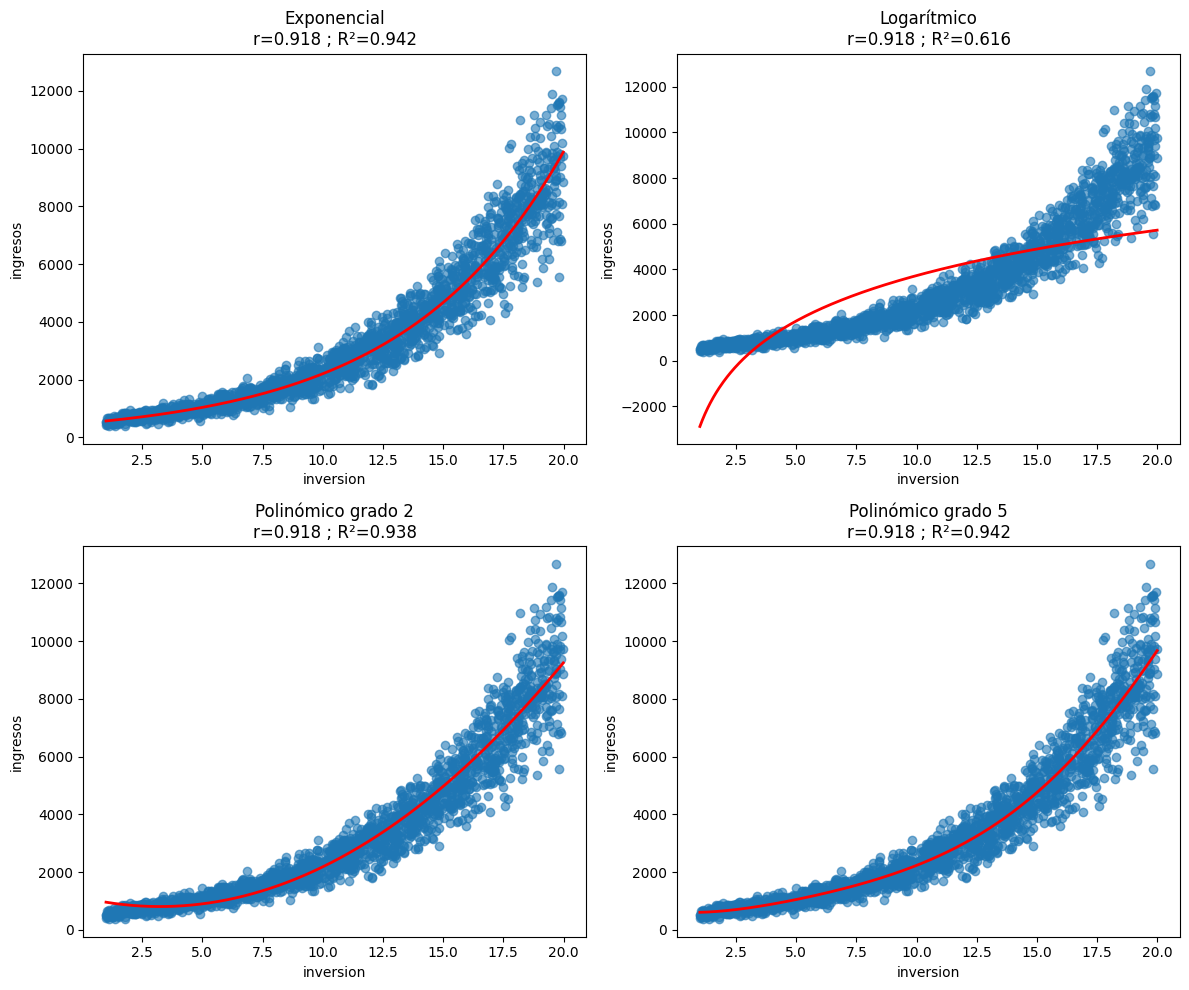

In [10]:
modelos = [modelo_exp, modelo_log, modelo_RP2, modelo_RP5]

titulos = [
    "Exponencial",
    "Logarítmico",
    "Polinómico grado 2",
    "Polinómico grado 5"
]

f_diagrama_dispersion_matriz(
    modelos,
    datos_entrenamiento,
    "inversion",
    "ingresos",
    titulos
)

### Homocedasticidad

En la **GRAFICA** se observa que ningún modelo ofrece una clara condición de homocedasticidad , tal vez de manera moderada el exponencial y polinómico de quinto nivel.


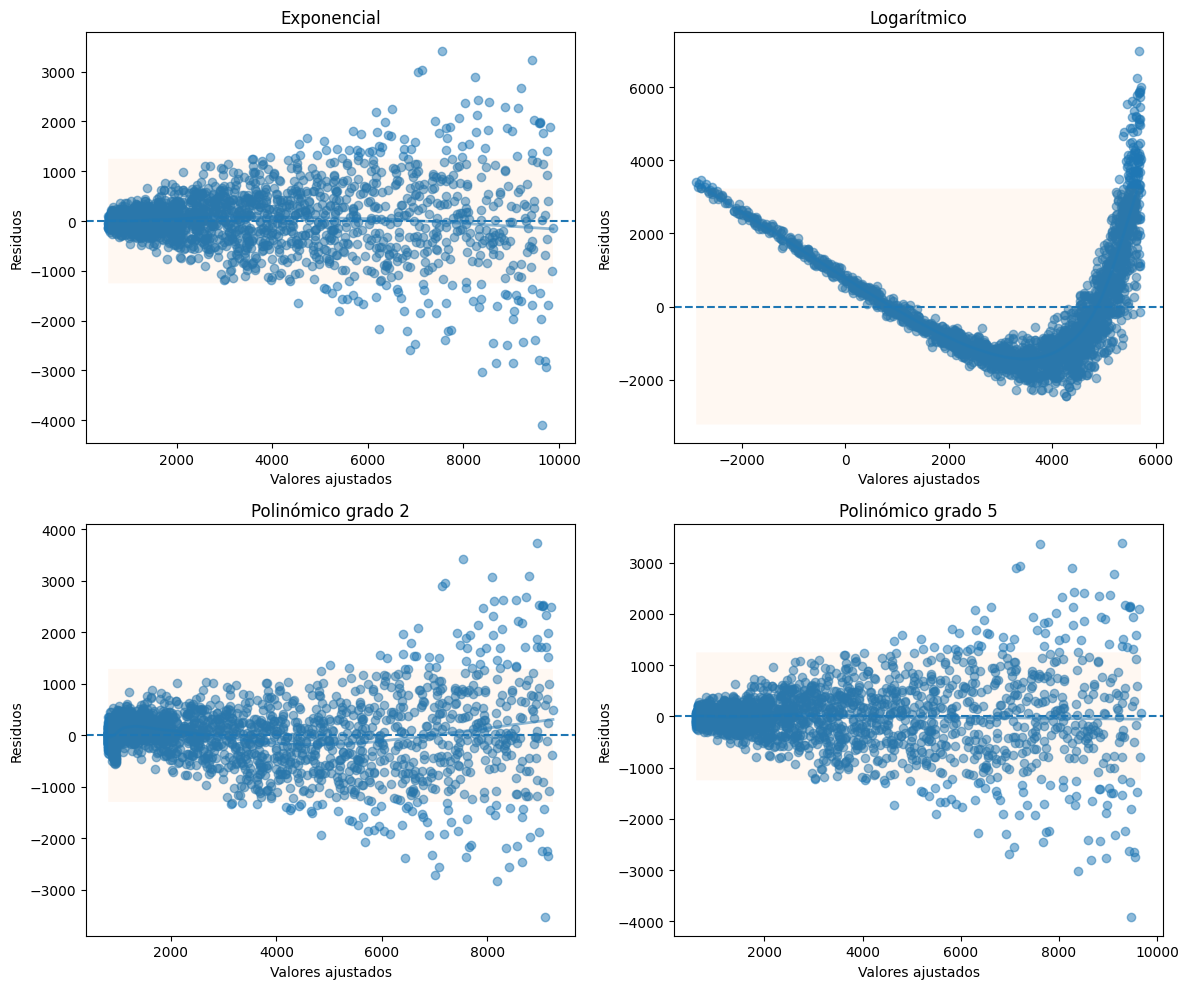

In [11]:
modelos = [modelo_exp, modelo_log, modelo_RP2, modelo_RP5]

titulos = [
    "Exponencial",
    "Logarítmico",
    "Polinómico grado 2",
    "Polinómico grado 5"
]

f_matriz_verificar_homocedasticidad(
    modelos,
    datos_entrenamiento,
    "inversion",
    "ingresos",
    titulos
)

### Normalidad


En la **GRAFICA** se observa que ningún modeLo ofrece clara distribución  normal en los residuos el que más se acerca es el modelo de regresión exponencial.


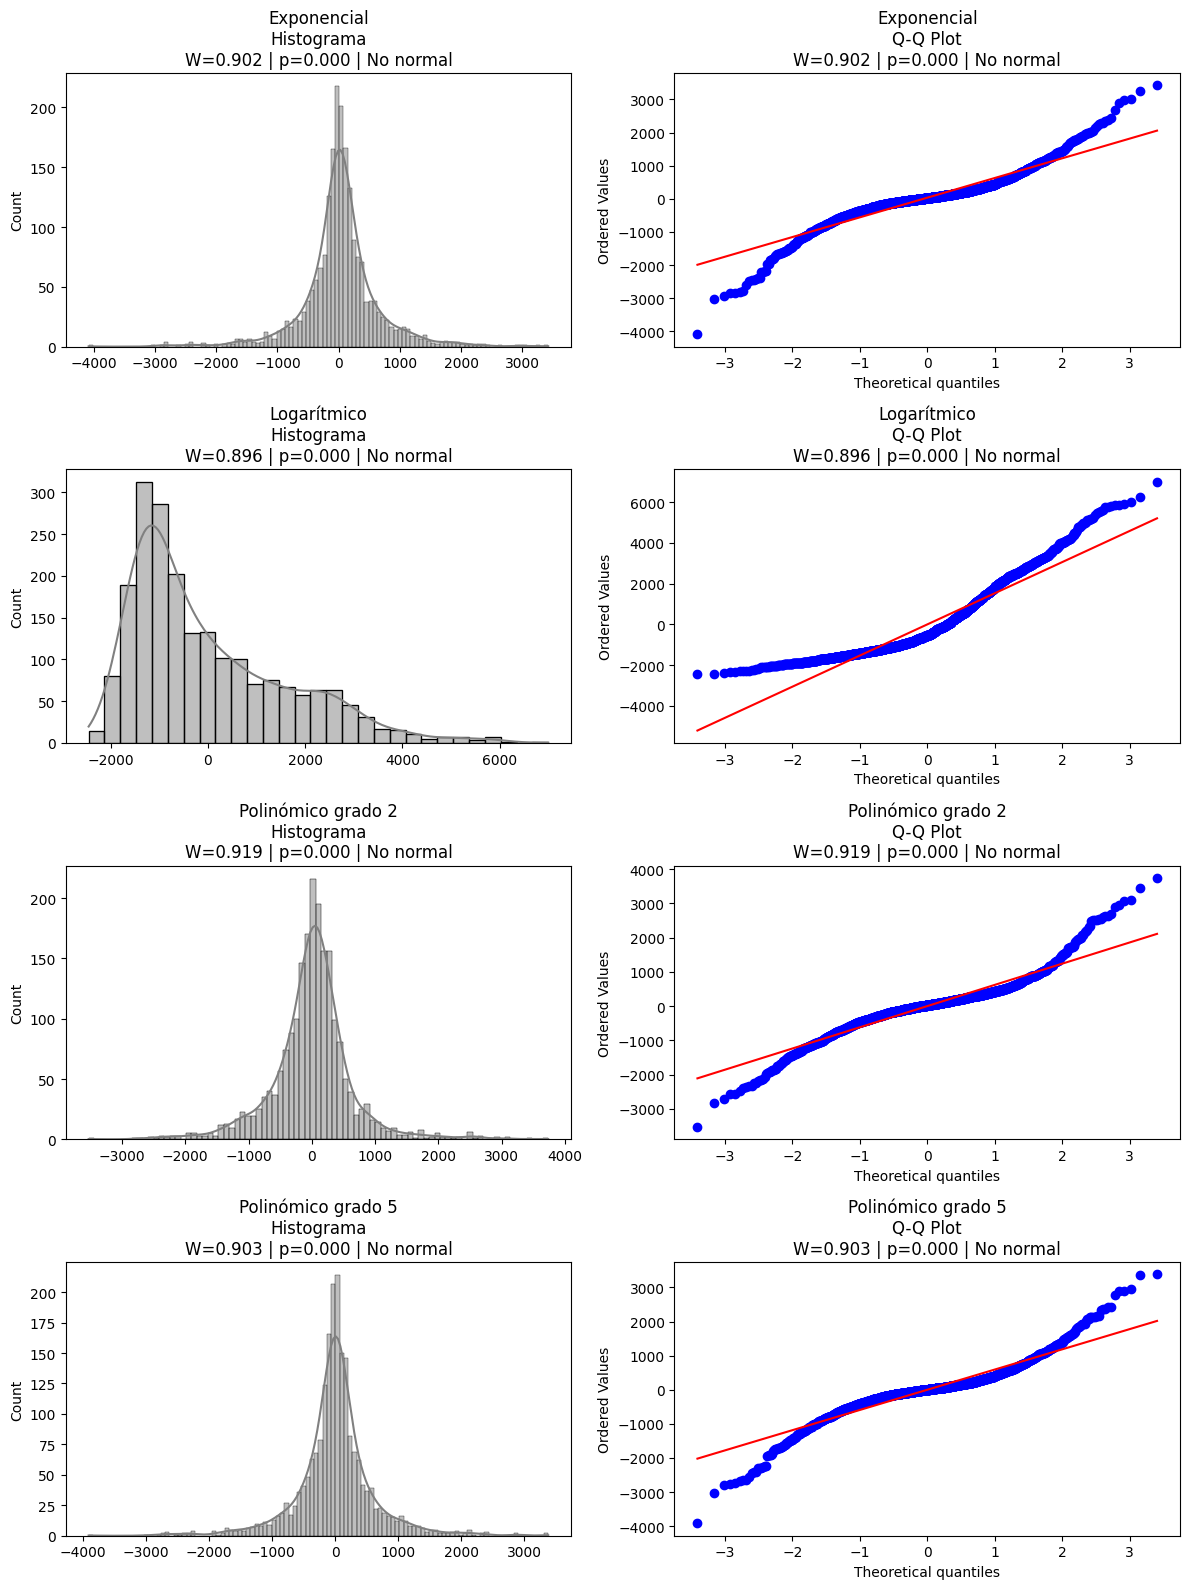

,Modelo,W,p_value,Normalidad,Ranking
0,Exponencial,0.9016,0.0,No normal,2.5
1,Logarítmico,0.8960,0.0,No normal,2.5
2,Polinómico grado 2,0.9187,0.0,No normal,2.5
3,Polinómico grado 5,0.9025,0.0,No normal,2.5


In [12]:
modelos = [modelo_exp, modelo_log, modelo_RP2, modelo_RP5]

titulos = [
    "Exponencial",
    "Logarítmico",
    "Polinómico grado 2",
    "Polinómico grado 5"
]

f_matriz_normalidad_modelos(
    modelos,
    datos_entrenamiento,
    "inversion",
    "ingresos",
    titulos
)

### Independencia de residuos

En la **GRAFICA** se observa que todos los modelos cumplen con el postulado de independencia de residuos y el estadístico de *Durbin Watson* en todos ellos es cercano a 2.


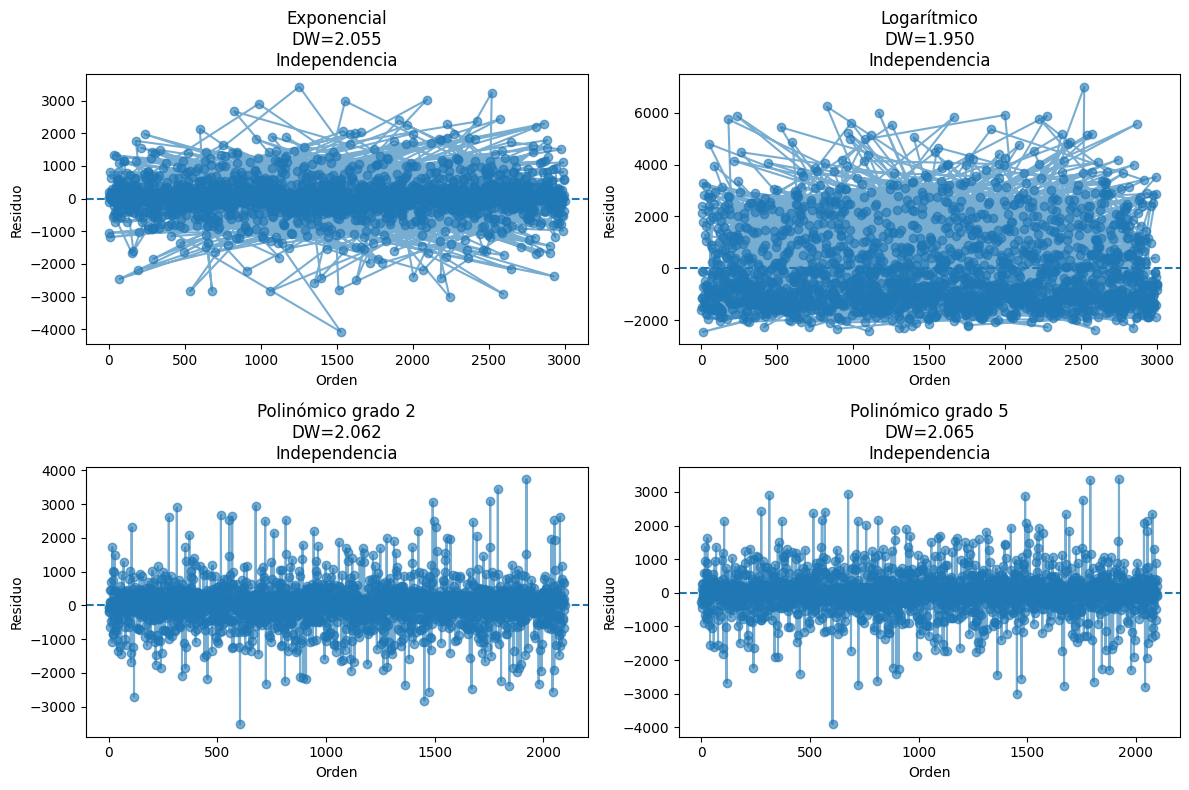

,Modelo,Durbin_Watson,Interpretacion,Distancia_2,Ranking
1,Logarítmico,1.9499,Independencia,0.0501,1.0
0,Exponencial,2.0552,Independencia,0.0552,2.0
2,Polinómico grado 2,2.0625,Independencia,0.0625,3.0
3,Polinómico grado 5,2.0645,Independencia,0.0645,4.0


In [13]:
modelos = [modelo_exp, modelo_log, modelo_RP2, modelo_RP5]

titulos = [
    "Exponencial",
    "Logarítmico",
    "Polinómico grado 2",
    "Polinómico grado 5"
]

f_verificar_independencia_residuos(
    modelos,
    datos_entrenamiento,
    "inversion",
    "ingresos",
    titulos
)

## Ecuaciones de los modelos

In [14]:
modelos = [modelo_exp, modelo_log, modelo_RP2, modelo_RP5]

titulos = [
    "Exponencial",
    "Logarítmico",
    "Polinómico grado 2",
    "Polinómico grado 5"
]

resultado = f_ecuaciones_modelos(
    modelos,
    titulos
)


 Exponencial

Coeficientes del modelo:
ln(a): 6.1971
b: 0.1501

Ecuación del modelo:
ŷ = 491.3447 · e^(0.1501·inversion)

 Logarítmico

Coeficientes del modelo:
Intercepto: -2879.7908
log(inversion): 2869.9572

Ecuación del modelo:
ŷ = -2879.7908 + 2869.9572·ln(inversion)

 Polinómico grado 2

Coeficientes del modelo:
Intercepto: 1125.659
inversion: -194.6076
inversion^2: 30.0494

Ecuación del modelo:
ŷ = 1125.659 - 194.6076·inversion + 30.0494·inversion^2

 Polinómico grado 5

Coeficientes del modelo:
Intercepto: 627.3965
inversion: -59.54
inversion^2: 47.2986
inversion^3: -5.0981
inversion^4: 0.3136
inversion^5: -0.0056

Ecuación del modelo:
ŷ = 627.3965 - 59.54·inversion + 47.2986·inversion^2 - 5.0981·inversion^3 + 0.3136·inversion^4 - 0.0056·inversion^5


## Evaluacón de los modelos

Al ejecutar la función que evalú alos modelos de regresión, el resultado indica que el mejor modelo en términos del estadístico *r square* es el polinómico de quinto grado, seguido del exponencial y luego el polinómico de segundo orden; estos rtes cumplen con la exigencia  de que tenga un valor por encima del *90%* que inciaoi,emt ese establecó como paraámetro para conccluir que es un buen modelo predictivo.

Ahora bien, con respecto al estadístico *RMSE* el modelo es el polinómico de quinto orden dado que es el que más cerca está en sus prediccones con respecto a los valores reales, seguido por tres unidades aproximadamente del modelo logarítmico.


In [15]:
modelos = [modelo_exp, modelo_log, modelo_RP2, modelo_RP5]

titulos = [
    "Exponencial",
    "Logarítmico",
    "Polinómico grado 2",
    "Polinómico grado 5"
]

resultado = f_evaluar_modelos_varios(
    modelos,
    datos_entrenamiento,
    "ingresos",
    "inversion",
    titulos
)

resultado

,R_square,R_square_ajustado,MSE,RMSE,Parametros (p),Modelo
3,0.9425,0.9423,3.889634e+05,623.6693,5,Polinómico grado 5
0,0.9420,0.9419,3.923719e+05,626.3960,1,Exponencial
2,0.9383,0.9383,4.167957e+05,645.5972,2,Polinómico grado 2
1,0.6156,0.6154,2.598363e+06,1611.9439,1,Logarítmico


# Interpretación

Este caso de estudio construye, evalúa y compara un modelo de regresión exponencial contra otros modelos como el logarítmico, polinomial de segundo y quinto grado.


El caso carga las lirberias y funciones previamente codificadas que permiten la adecuada ejecucuón de este caso.

Los datos que se utilizan se encuentran en el enlace https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/inversion_publicidad_e_ingresos.csv

Las funciones que codificaron con ayuda de intelgiencia artifical generativa y con verificación del autor se encuentran en el enlace https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/Python%20NoteBooks/funciones/funciones_MExp.py

Para recrear todo el caso este se encuentra en el enlace: https://colab.research.google.com/drive/1_HPYl4WnVMn8QBMfde3xHtmeLjhvklCL?usp=sharing

De igual forma el caso de estudio se puede encontrar en plataforma *github* en el espacio del autor: https://github.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/blob/main/Python%20NoteBooks/Caso_Modelo_Exponencial_inversion_ingresos.ipynb

En términos de valoración de los postulados se puede decir que los modelos exponencial y polinómicos cumplen con la linealidad de los residuos con los valores estimados correspondientes, no así el modelo logarítmico.

Ningún modelo cumple totalmente con el postulado de homocedasticidad y normalidad de residuos.

Todos los modelos satisfacen el postulado de independencia de residuos.

El mejor modelo en términos de calidad predicitiva es el polinómico de quinto nivel.

El modelo que no cumple con el rendimiento predicitivo esperado de tener un valor *90%* o superior en el estadístico *r square* es el logarítmico por lo que quieda descartado como modelo predicitivo para estos datos.

Los resultados obtenidos de este caso de estudio con programación *Python* son similares a los encontrados en el caso de estudio con programamción *R*.